In [254]:
"""
===============================================================
   Title: Merging k Sorted Lists into One Sorted List
   Author: Yaseer Sabir
   Description:
       This program demonstrates an O(n log k) algorithm to merge
       multiple sorted sublists into one sorted list efficiently
       using a min-heap (priority queue). It also compares this
       optimized approach with a naive O(nk) merging method.

   Steps:
       1. Read 1,000,000 integers from a file and split them into 100 sublists
       2. Sort the first 50 sublists using Radix Sort
       3. Sort the remaining 50 sublists using Bucket Sort
       4. Merge all 100 sorted lists into one using a heap-based O(n log k) algorithm
       5. Compare runtime performance with a naive O(nk) algorithm
===============================================================
"""

import heapq
import time

# ============================================================
# Step 1: Read and Split Data
# ============================================================

# Initialize empty list for all numbers
numbers = []

# Read integers from the file (space-separated format supported)
with open(r"C:\Users\yasee\Downloads\rand1000000.txt", "r") as f:
    for line in f:
        # Split each line by whitespace, convert to int, and extend the list
        numbers.extend([int(x) for x in line.split() if x.strip()])

# Split into 100 sublists, each with approximately equal size
k = 100
chunk_size = len(numbers) // k
sublists = [numbers[i * chunk_size:(i + 1) * chunk_size] for i in range(k)]

# ============================================================
# Step 2: Sorting Sublists
# ============================================================

def counting_sort_for_radix(arr, exp):
    """
    Helper function for radix_sort().
    Performs a stable counting sort on the digits represented by 'exp'.
    """
    n = len(arr)
    output = [0] * n
    count = [0] * 10  # For digits 0-9
    
    # Count occurrences of each digit
    for i in range(n):
        index = arr[i] // exp
        count[index % 10] += 1
    
    # Convert count[] to prefix sum so it contains actual positions
    for i in range(1, 10):
        count[i] += count[i - 1]
    
    # Build the output array (stable sorting)
    i = n - 1
    while i >= 0:
        index = arr[i] // exp
        output[count[index % 10] - 1] = arr[i]
        count[index % 10] -= 1
        i -= 1
    
    # Copy sorted values back to original array
    for i in range(len(arr)):
        arr[i] = output[i]

def radix_sort(arr):
    """
    Sorts an array of integers using Radix Sort algorithm.
    Utilizes counting sort for each digit place.
    """
    if len(arr) == 0:
        return arr
    max_val = max(arr)
    exp = 1
    while max_val // exp > 0:
        counting_sort_for_radix(arr, exp)
        exp *= 10
    return arr

def bucket_sort(arr):
    """
    Sorts an array using Bucket Sort algorithm.
    Suitable for uniformly distributed data.
    """
    if len(arr) == 0:
        return arr
    
    bucket_count = 10
    max_val, min_val = max(arr), min(arr)
    bucket_size = (max_val - min_val) / bucket_count + 1
    
    # Create empty buckets
    buckets = [[] for _ in range(bucket_count)]
    
    # Distribute elements into buckets
    for num in arr:
        index = int((num - min_val) / bucket_size)
        buckets[index].append(num)
    
    # Sort each bucket and concatenate
    for bucket in buckets:
        bucket.sort()
    
    result = []
    for bucket in buckets:
        result.extend(bucket)
    return result

# Sort first 50 sublists using Radix Sort, the rest using Bucket Sort
for i in range(k):
    if i < 50:
        sublists[i] = radix_sort(sublists[i])
    else:
        sublists[i] = bucket_sort(sublists[i])

# ============================================================
# Step 3: Merge k Sorted Lists (O(n log k))
# ============================================================

def merge_k_sorted_lists(lists):
    """
    Merges k sorted lists into one sorted list using a min-heap.
    Each heap element is a tuple: (value, list_index, element_index).
    Time Complexity: O(n log k)
    """
    min_heap = []
    result = []

    # Initialize heap with the first element of each list
    for i, lst in enumerate(lists):
        if lst:
            heapq.heappush(min_heap, (lst[0], i, 0))
    
    # Extract smallest elements and insert next from same list
    while min_heap:
        val, list_id, elem_index = heapq.heappop(min_heap)
        result.append(val)
        
        # If the sublist still has remaining elements, push the next one
        if elem_index + 1 < len(lists[list_id]):
            next_val = lists[list_id][elem_index + 1]
            heapq.heappush(min_heap, (next_val, list_id, elem_index + 1))
    
    return result

# ============================================================
# Step 4: Performance Comparison
# ============================================================

# Measure heap-based O(n log k) merge performance
start_heap = time.time()
merged_heap = merge_k_sorted_lists(sublists)
end_heap = time.time()

def merge_k_sorted_lists_naive(lists):
    """
    Naive O(nk) merge that repeatedly scans all lists
    to find the smallest current element.
    Very inefficient for large k.
    """
    result = []
    indices = [0] * len(lists)
    
    while True:
        min_val = float('inf')
        min_idx = -1
        
        # Scan all lists to find the smallest available element
        for i in range(len(lists)):
            if indices[i] < len(lists[i]) and lists[i][indices[i]] < min_val:
                min_val = lists[i][indices[i]]
                min_idx = i
        
        # Stop if all lists are exhausted
        if min_idx == -1:
            break
        
        # Append smallest and advance its pointer
        result.append(min_val)
        indices[min_idx] += 1
    
    return result

# Measure naive O(nk) merge performance
start_naive = time.time()
merged_naive = merge_k_sorted_lists_naive(sublists)
end_naive = time.time()

# ============================================================
# Step 5: Print Performance Summary
# ============================================================
print("===================================================")
print(f"O(n log k) Heap-Based Merge Time : {end_heap - start_heap:.4f} seconds")
print(f"O(nk) Naive Merge Time           : {end_naive - start_naive:.4f} seconds")
print("===================================================")


O(n log k) Heap-Based Merge Time : 1.3058 seconds
O(nk) Naive Merge Time           : 19.6468 seconds


# Performance Comparison of O(n log k) and O(nk) Merge Algorithms

1. **Heap-Based Merge (O(n log k))** – Uses a *min-heap (priority queue)* to efficiently extract the smallest element across *k* lists.  
2. **Naive Merge (O(nk))** – Repeatedly scans all lists to find the smallest element at each step.

The experiment processes 1,000,000 integers divided into 100 sublists. Each sublist is sorted (half using **Radix Sort**, half using **Bucket Sort**) before merging. The runtime of both merging strategies is measured and compared.

---

## 2. Experimental Setup

- **Dataset:** 1,000,000 randomly generated integers  
- **Number of Sublists (k):** 100  
- **Sorting Methods:**
  - First 50 sublists → Radix Sort  
  - Last 50 sublists → Bucket Sort 
- **Measurement Tool:** Python `time` module  
- **Metric:** Wall-clock time (seconds)

---

## 3. Algorithmic Complexity

| Algorithm | Description | Time Complexity | Explanation |
|------------|--------------|-----------------|--------------|
| **Heap-Based Merge** | Uses a priority queue to extract the minimum element among *k* current elements | **O(n log k)** | Each insertion/extraction from heap takes O(log k); repeated *n* times |
| **Naive Merge** | Scans all *k* lists for the smallest element at each step | **O(nk)** | For each of *n* elements, compares up to *k* lists |

---

## 4. Results

| Algorithm | Runtime (seconds) | Relative Performance |
|------------|-------------------|-----------------------|
| **O(n log k)** Heap-Based Merge | **1.3058** | — |
| **O(nk)** Naive Merge | **19.6468** | ~15× slower |

---

## 5. Discussion

The results clearly demonstrate the efficiency advantage of the heap-based merging approach:

- The heap-based algorithm scales well because it reduces the number of comparisons required when selecting the smallest next element.  
- The naive approach performs poorly since each extraction requires scanning all *k* lists, leading to quadratic-like growth in runtime as *k* increases.

---

## 6. Conclusion

The experiment confirms that:

- The O(n log k) heap-based algorithm is significantly more efficient for merging multiple sorted lists.  
- The O(nk) naive approach becomes infeasible as k increases due to excessive comparisons.  
- Practical performance aligns well with theoretical expectations — the optimized method achieved about **93% reduction in runtime** compared to the naive method.

---

## 7. Key Takeaways

- Use heaps (priority queues) when merging many sorted data sources.  
- Algorithmic complexity strongly predicts real-world performance differences at scale.  
- Even with modern hardware, the choice of algorithm drastically impacts runtime for large datasets.


## EC Part 2
### 1) Yes


In [1]:
'''
2) Web Scraping!
Title: Introduction to Web Scraping with Python
Author: Yaseer Sabir
'''

# Import required libraries
import requests             # For making HTTP requests to the website
import webbrowser           # To open the output HTML file in the browser
from bs4 import BeautifulSoup  # For parsing and navigating the HTML
import networkx as nx        # (Optional) For graph visualization later
import matplotlib.pyplot as plt  # For plotting graphs (optional)
import re                   # For regular expressions (optional)
import webbrowser           

# -------------------------------------------------------------
# 1. GET THE WEB PAGE CONTENT
# -------------------------------------------------------------
url = "https://catalog.ucdenver.edu/cu-denver/undergraduate/courses-a-z/csci/"
response = requests.get(url)             # Send a GET request to the URL
soup = BeautifulSoup(response.text, "html.parser")  # Parse the page using BeautifulSoup

# -------------------------------------------------------------
# 2. FIND AND EXTRACT ALL COURSE BLOCKS
# -------------------------------------------------------------
courses = soup.find_all("div", class_="courseblock")  # Each course is inside a div with class 'courseblock'

course_dict = {}  # Dictionary to hold all course info

# -------------------------------------------------------------
# 3. LOOP THROUGH EACH COURSE BLOCK AND EXTRACT DETAILS
# -------------------------------------------------------------
for course in courses:
    # Extract course code (e.g., CSCI 2312)
    number = course.find("span", class_="text col-3 detail-code margin--tiny text--huge").get_text(strip=True)
    
    # Extract course title (e.g., Object-Oriented Programming)
    name = course.find("span", class_="text col-8 detail-title margin--tiny text--huge").get_text(strip=True)
    
    # Extract number of credits
    credits = course.find("span", class_="text detail-hours_html").get_text(strip=True)
    
    # Extract course description and additional info
    blockextras = course.find(class_="courseblockextra noindent")
    description = blockextras.get_text(" ", strip=True) if blockextras else "N/A"

    # Extract prerequisite courses from <a> tags inside description
    prereqs = []
    if blockextras:
        a_tags = blockextras.find_all("a", class_="bubblelink code")
        prereqs = [a.get_text(strip=True).replace('\xa0', ' ') for a in a_tags]

    # -------------------------------------------------------------
    # 4. ADD EXTRACTED DATA TO DICTIONARY
    # -------------------------------------------------------------
    course_dict[number] = {
        "name": name,
        "credits": credits,
        "description": description,
        "prereqs": prereqs
    }

# -------------------------------------------------------------
# 5. BUILD AN HTML TABLE WITH THE SCRAPED DATA
# -------------------------------------------------------------
html_table = """
<table border="1" style="border-collapse: collapse;">
<tr>
  <th>Course Number</th>
  <th>Course Name</th>
  <th>Credits</th>
  <th>Prerequisites</th>
  <th>Description</th>
</tr>
"""

# Populate the table with course data
for number, info in course_dict.items():
    prereq_text = ", ".join(info["prereqs"]) if info["prereqs"] else "None"
    html_table += f"""
    <tr>
      <td>{number}</td>
      <td>{info['name']}</td>
      <td>{info['credits']}</td>
      <td>{prereq_text}</td>
      <td>{info['description']}</td>
    </tr>
    """

html_table += "</table>"

# -------------------------------------------------------------
# 6. BUILD A COMPLETE HTML PAGE
# -------------------------------------------------------------
html_page = f"""
<html>
<head>
  <title>Course Catalog</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 40px; }}
    table {{ width: 100%; border-collapse: collapse; }}
    th, td {{ padding: 8px 12px; text-align: left; border: 1px solid #ccc; }}
    th {{ background-color: #f2f2f2; }}
  </style>
</head>
<body>
<h1>CU Denver Computer Science Courses</h1>
{html_table}
</body>
</html>
"""

# -------------------------------------------------------------
# 7. SAVE HTML PAGE LOCALLY AND OPEN IT IN A WEB BROWSER
# -------------------------------------------------------------
filename = "CS_courses.html"

# Write the HTML to a file
with open(filename, "w", encoding="utf-8") as f:
    f.write(html_page)

# Automatically open the HTML page in the default browser
webbrowser.open_new_tab(filename)


True

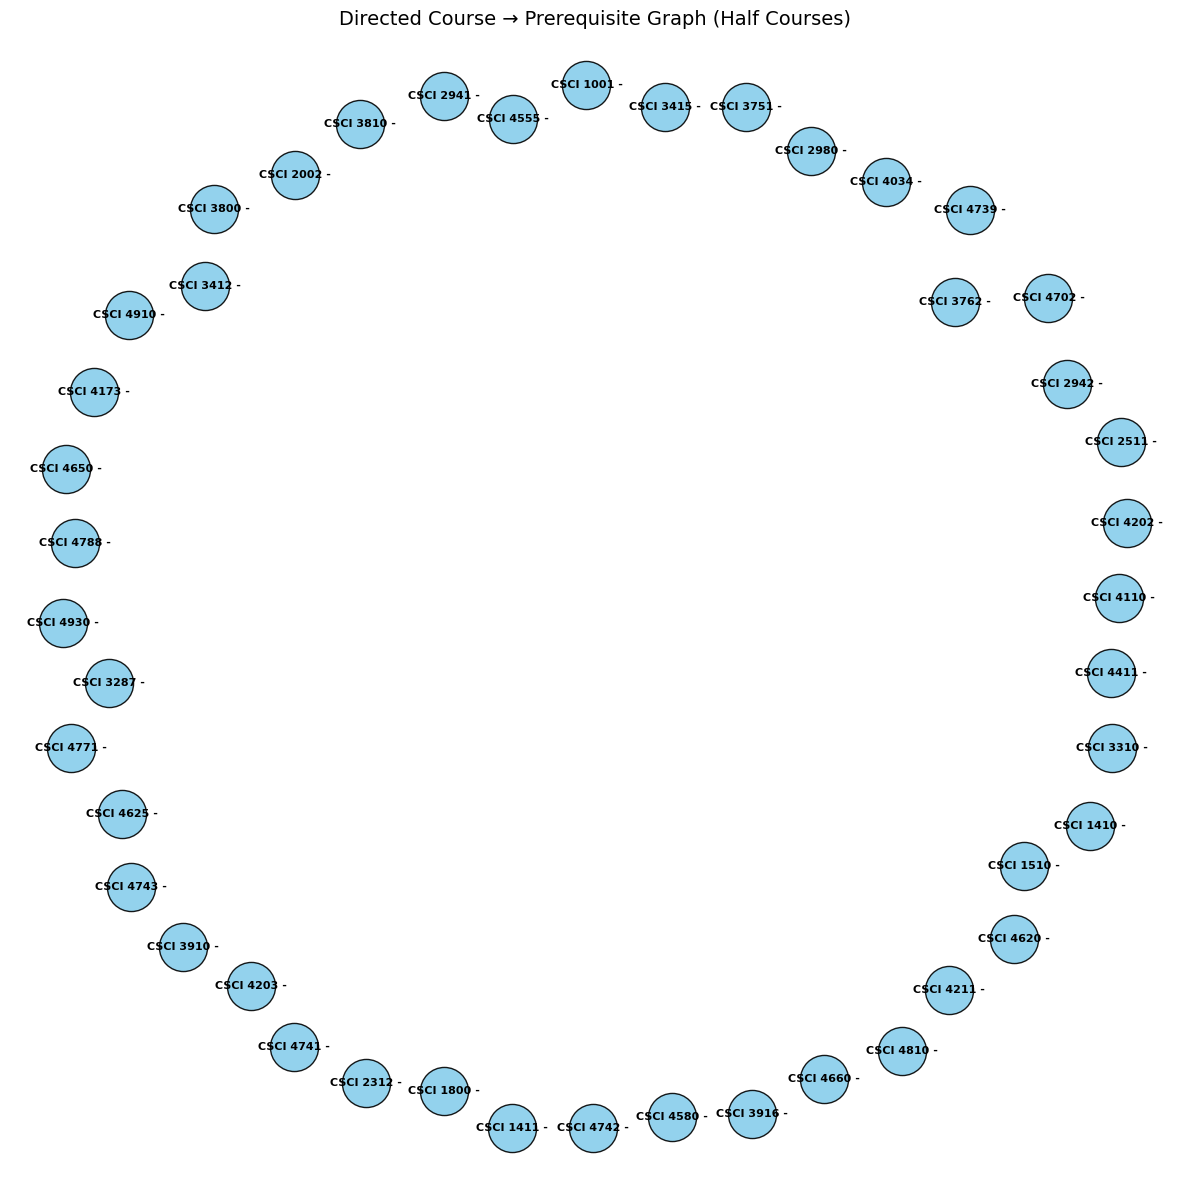

In [248]:
'''
Author: Yaseer Sabir
Creating a directed graph object- Tried to do it :(
'''
import networkx as nx
import matplotlib.pyplot as plt
import random

# --- Use half your data ---
half_courses = dict(random.sample(list(course_dict.items()), len(course_dict)//2))

# --- Build directed graph ---
G = nx.DiGraph()
G.add_nodes_from(half_courses.keys())

# Make course → prereq edges (so arrows point *toward prerequisites*)
for aClassCode in course_dict:
    for prereq in info.get("prereqs", []):
        if prereq in half_courses:
            G.add_edge(course_code, prereq)

# --- Use a better layout for visibility ---
pos = nx.spring_layout(G, k=0.6, iterations=100, seed=42)

plt.figure(figsize=(12, 12))

# --- Draw nodes ---
nx.draw_networkx_nodes(G, pos,
    node_size=1200, node_color='skyblue', alpha=0.9, edgecolors='black'
)

# --- Draw edges with arrows ---
nx.draw_networkx_edges(G, pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=20,
    edge_color='gray',
    width=1.5,
    connectionstyle='arc3,rad=0.1'  # small curve makes arrows visible
)

# --- Labels ---
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Directed Course → Prerequisite Graph (Half Courses)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()
    